<a href="https://colab.research.google.com/github/acaae/tugas-machine-learning/blob/main/KELOMPOK_C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

def penjepit(z):                                   # nama resmi: sigmoid
    return 1 / (1 + np.exp(-z))

def latih_peluang(X, y, eta=0.5, putaran=2000, cetak=True):
    """Regresi logistik dari nol: tebak -> ukur meleset (hukuman) -> geser. Mengembalikan w, b, mu, sd."""
    mu, sd = X.mean(0), X.std(0)
    Xz = (X - mu) / sd                             # samakan volume
    w, b = np.zeros(X.shape[1]), 0.0
    for i in range(putaran):
        p = penjepit(Xz @ w + b)                   # LANGKAH 1: tebak
        galat = p - y                              # LANGKAH 2: meleset
        w -= eta * Xz.T @ galat / len(y)           # LANGKAH 3: geser
        b -= eta * galat.mean()
        if cetak and i % 500 == 0:
            hukuman = -np.mean(y*np.log(p+1e-9) + (1-y)*np.log(1-p+1e-9))
            print(f"iter {i:4d}  hukuman={hukuman:.4f}")
    return w, b, mu, sd

def peluang_dari(X, w, b, mu, sd):
    return penjepit(((X - mu) / sd) @ w + b)

# data booking sintetis Kode #2 (800 baris, kenop "rahasia" -1.8 / 0.025 / -1.2)
rng = np.random.default_rng(11)
lead    = rng.integers(0, 200, 800)
deposit = (rng.random(800) < 0.35).astype(float)
X2 = np.c_[lead, deposit]
y2 = (rng.random(800) < penjepit(-1.8 + 0.025*lead - 1.2*deposit)).astype(int)

w2, b2, mu2, sd2 = latih_peluang(X2, y2)
peluang2 = peluang_dari(X2, w2, b2, mu2, sd2)
print(pd.DataFrame({"lead": lead[:5], "deposit": deposit[:5].astype(int),
                    "peluang": peluang2[:5].round(2), "curiga": (peluang2[:5] >= 0.5).astype(int), "kenyataan": y2[:5]}))

iter    0  hukuman=0.6931
iter  500  hukuman=0.4887
iter 1000  hukuman=0.4887
iter 1500  hukuman=0.4887
   lead  deposit  peluang  curiga  kenyataan
0    26        0     0.25       0          0
1    25        0     0.24       0          1
2   159        0     0.91       1          1
3    99        1     0.38       0          1
4   118        0     0.78       1          1


In [4]:
def tabel_batas(peluang, y, daftar_batas=(0.3, 0.5, 0.7), rugi_kosong=0.8, rugi_tersinggung=0.25):
    """rugi dalam juta rupiah per kejadian — ASUMSI, tulis eksplisit di laporan."""
    baris = []
    for batas in daftar_batas:
        curiga = peluang >= batas
        tertangkap  = int((curiga & (y == 1)).sum())
        salah_tuduh = int((curiga & (y == 0)).sum())
        lolos       = int((~curiga & (y == 1)).sum())
        presisi = tertangkap / max(tertangkap + salah_tuduh, 1)
        recall  = tertangkap / max(tertangkap + lolos, 1)
        rugi    = lolos * rugi_kosong + salah_tuduh * rugi_tersinggung
        baris.append([batas, tertangkap, salah_tuduh, lolos, round(presisi, 2), round(recall, 2), round(rugi, 1)])
    return pd.DataFrame(baris, columns=["batas", "tertangkap", "salah_tuduh", "lolos", "presisi", "recall", "E_rugi_jt"])

tabel = tabel_batas(peluang2, y2)
print(tabel)
print("\nBatas dengan kerugian terkecil (asumsi kosong 0,8 jt / tersinggung 0,25 jt):", tabel.loc[tabel.E_rugi_jt.idxmin(), "batas"])
print("Kalau biaya tersinggung naik 3x (0,75 jt):", tabel_batas(peluang2, y2, rugi_tersinggung=0.75).pipe(lambda t: t.loc[t.E_rugi_jt.idxmin(), "batas"]))

   batas  tertangkap  salah_tuduh  lolos  presisi  recall  E_rugi_jt
0    0.3         400          170     36     0.70    0.92       71.3
1    0.5         342          101     94     0.77    0.78      100.5
2    0.7         269           46    167     0.85    0.62      145.1

Batas dengan kerugian terkecil (asumsi kosong 0,8 jt / tersinggung 0,25 jt): 0.3
Kalau biaya tersinggung naik 3x (0,75 jt): 0.5


In [5]:
rng = np.random.default_rng(11)

# ---------- data listing (400 baris) ----------
n = 400
kamar  = rng.integers(1, 5, n)
jarak  = rng.gamma(2.0, 1.2, n).round(2)
rating = rng.normal(4.2, 0.4, n).clip(1, 5).round(1)
harga  = (350 + 620*kamar - 175*jarak + 90*rating + rng.normal(0, 120, n)).round()
X = np.c_[kamar, jarak, rating].astype(float)
mu, sd = X.mean(0), X.std(0)
Xz = (X - mu) / sd                                   # samakan volume (z-score)

# ---------- BAGIAN A : menebak harga ----------
w, b, eta = np.zeros(3), 0.0, 0.2
for i in range(400):
    galat = (Xz @ w + b) - harga                     # langkah 1+2
    w -= eta * 2 * (Xz.T @ galat) / n ; b -= eta * 2 * galat.mean()   # langkah 3
    if i % 50 == 0: print(i, "akar meleset =", round(np.sqrt(np.mean(galat**2)), 1))
w_asli = w / sd ; b_asli = b - (w_asli * mu).sum()
print("harga = %.0f + %.0f*kamar %+.0f*jarak %+.0f*rating" % (b_asli, *w_asli))
print("(kenop yang ditanam: 350, 620, -175, 90)")

0 akar meleset = 1989.4
50 akar meleset = 115.5
100 akar meleset = 115.5
150 akar meleset = 115.5
200 akar meleset = 115.5
250 akar meleset = 115.5
300 akar meleset = 115.5
350 akar meleset = 115.5
harga = 347 + 631*kamar -176*jarak +84*rating
(kenop yang ditanam: 350, 620, -175, 90)


In [6]:
# ---------- data booking (800 baris) ----------
m = 800
lead    = rng.integers(0, 200, m)
deposit = (rng.random(m) < 0.35).astype(float)
z_asli  = -1.8 + 0.025*lead - 1.2*deposit
batal   = (rng.random(m) < 1/(1+np.exp(-z_asli))).astype(float)

# ---------- BAGIAN B : menebak peluang ----------
Xb = np.c_[lead, deposit].astype(float)
wb, bb, mub, sdb = latih_peluang(Xb, batal)
print("kenop (satuan asli):", (wb / sdb).round(3), "harga dasar:", round(bb - (wb / sdb * mub).sum(), 2), "  (ditanam: 0.025, -1.2, -1.8)")
for lt, dp in [(10, 1), (90, 0), (180, 0)]:
    print(f"lead {lt:3d}, deposit {dp}: P(batal) =", peluang_dari(np.array([[lt, dp]]), wb, bb, mub, sdb).round(2)[0])

iter    0  hukuman=0.6931
iter  500  hukuman=0.4971
iter 1000  hukuman=0.4971
iter 1500  hukuman=0.4971
kenop (satuan asli): [ 0.026 -1.294] harga dasar: -1.86   (ditanam: 0.025, -1.2, -1.8)
lead  10, deposit 1: P(batal) = 0.05
lead  90, deposit 0: P(batal) = 0.63
lead 180, deposit 0: P(batal) = 0.95


In [7]:
# ---------- BAGIAN C : batas curiga & biaya ----------
p_lab = peluang_dari(Xb, wb, bb, mub, sdb)
RUGI_KOSONG, RUGI_TERSINGGUNG = 0.8, 0.25            # juta Rp — ASUMSI, tulis eksplisit
tabel_lab = tabel_batas(p_lab, batal.astype(int), rugi_kosong=RUGI_KOSONG, rugi_tersinggung=RUGI_TERSINGGUNG)
print(tabel_lab)
print("Rekomendasi batas:", tabel_lab.loc[tabel_lab.E_rugi_jt.idxmin(), "batas"])

   batas  tertangkap  salah_tuduh  lolos  presisi  recall  E_rugi_jt
0    0.3         401          182     44     0.69    0.90       80.7
1    0.5         361          107     84     0.77    0.81       94.0
2    0.7         278           46    167     0.86    0.62      145.1
Rekomendasi batas: 0.3


In [8]:
import os, urllib.request
URL_AIRBNB = "https://data.insideairbnb.com/thailand/central-thailand/bangkok/2026-06-29/data/listings.csv.gz"
FILE_AIRBNB = "listings_bangkok.csv.gz"
if not os.path.exists(FILE_AIRBNB):
    try:
        urllib.request.urlretrieve(URL_AIRBNB, FILE_AIRBNB); print("unduh selesai")
    except Exception as e:
        print("unduh gagal:", e, "\n→ unduh manual dari https://insideairbnb.com/get-the-data/ (Bangkok → listings.csv.gz)")
raw = pd.read_csv(FILE_AIRBNB, low_memory=False)
print(raw.shape)

unduh selesai
(31069, 90)


In [9]:
# --- pembersihan ---
fitur = ["bedrooms", "accommodates", "number_of_reviews", "review_scores_rating", "minimum_nights", "beds"]
df = raw[fitur + ["price"]].copy()
df["price"] = df["price"].astype(str).str.replace(r"[$,]", "", regex=True)
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df = df.dropna()
df = df[df["price"] > 0]
batas_atas = df["price"].quantile(0.99)             # buang pencilan harga di atas persentil 99
df = df[df["price"] <= batas_atas]
print("baris setelah bersih:", len(df), "| pencilan dibuang di atas", round(batas_atas), "THB")

# --- bagi 80/20 ---
rng = np.random.default_rng(0)
idx = rng.permutation(len(df)); potong = int(0.8 * len(df))
latih, uji = df.iloc[idx[:potong]], df.iloc[idx[potong:]]
X_latih, y_latih = latih[fitur].to_numpy(float), latih["price"].to_numpy(float)
X_uji,   y_uji   = uji[fitur].to_numpy(float),   uji["price"].to_numpy(float)

# --- samakan volume HANYA dari data latih ---
mu, sd = X_latih.mean(0), X_latih.std(0)
Xz_latih, Xz_uji = (X_latih - mu) / sd, (X_uji - mu) / sd

# --- tiga langkah (gradient descent) ---
w, b, eta = np.zeros(len(fitur)), 0.0, 0.1
for i in range(1500):
    galat = Xz_latih @ w + b - y_latih
    w -= eta * 2 * Xz_latih.T @ galat / len(y_latih) ; b -= eta * 2 * galat.mean()
    if i % 300 == 0: print(f"iter {i:4d}  RMSE latih = {np.sqrt(np.mean(galat**2)):8.1f}")

rmse_latih = np.sqrt(np.mean((Xz_latih @ w + b - y_latih)**2))
rmse_uji   = np.sqrt(np.mean((Xz_uji   @ w + b - y_uji)**2))
print(f"\nRMSE latih = {rmse_latih:.1f} THB | RMSE uji = {rmse_uji:.1f} THB | harga rata-rata = {y_latih.mean():.0f} THB")

# --- kembalikan ke satuan asli & simpan ---
w_asli = w / sd ; b_asli = b - (w_asli * mu).sum()
bobot = pd.DataFrame({"fitur": ["harga_dasar"] + fitur, "bobot_THB": np.r_[b_asli, w_asli].round(1)})
print(bobot)
bobot.to_csv("bobot_terlatih.csv", index=False)
# Penafsiran (tulis di sel Markdown): tiap +1 kamar tidur → harga naik ± bobot 'bedrooms' THB, dengan fitur lain ditahan.
# Fitur yang bisa diubah host: minimum_nights, (jangka panjang) bedrooms/beds; yang tidak: number_of_reviews, rating (hasil, bukan tombol).

baris setelah bersih: 16085 | pencilan dibuang di atas 16151 THB
iter    0  RMSE latih =   3098.2
iter  300  RMSE latih =   1468.8
iter  600  RMSE latih =   1468.8
iter  900  RMSE latih =   1468.8
iter 1200  RMSE latih =   1468.8

RMSE latih = 1468.8 THB | RMSE uji = 1469.6 THB | harga rata-rata = 2326 THB
                  fitur  bobot_THB
0           harga_dasar     -160.1
1              bedrooms      297.7
2          accommodates      529.6
3     number_of_reviews       -1.0
4  review_scores_rating      164.2
5        minimum_nights      -25.2
6                  beds     -137.7


In [10]:
URL_HOTEL = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
FILE_HOTEL = "hotel_bookings.csv"
if not os.path.exists(FILE_HOTEL):
    urllib.request.urlretrieve(URL_HOTEL, FILE_HOTEL); print("unduh selesai")
hb = pd.read_csv(FILE_HOTEL)
print(hb.shape); print(hb["is_canceled"].mean().round(3), "= P(batal) keseluruhan")
print(hb.groupby("deposit_type")["is_canceled"].mean().round(3))

unduh selesai
(119390, 32)
0.37 = P(batal) keseluruhan
deposit_type
No Deposit    0.284
Non Refund    0.994
Refundable    0.222
Name: is_canceled, dtype: float64


In [11]:
# --- fitur: lead_time, deposit_type (one-hot), previous_cancellations, total_of_special_requests, booking_changes ---
d = hb[["lead_time", "deposit_type", "previous_cancellations", "total_of_special_requests", "booking_changes", "is_canceled"]].dropna()
d = pd.get_dummies(d, columns=["deposit_type"], drop_first=True)     # Non Refund, Refundable (No Deposit = acuan)
fitur_b = [c for c in d.columns if c != "is_canceled"]
Xall, yall = d[fitur_b].to_numpy(float), d["is_canceled"].to_numpy(int)

# bagi 80/20
rng = np.random.default_rng(0)
idx = rng.permutation(len(d)); potong = int(0.8 * len(d))
X_latih, y_latih = Xall[idx[:potong]], yall[idx[:potong]]
X_uji,   y_uji   = Xall[idx[potong:]], yall[idx[potong:]]

# latih (mu, sd hanya dari data latih — di dalam fungsi)
wb, bb, mub, sdb = latih_peluang(X_latih, y_latih, eta=0.5, putaran=3000)
p_latih = peluang_dari(X_latih, wb, bb, mub, sdb)
p_uji   = peluang_dari(X_uji,   wb, bb, mub, sdb)

def log_loss(y, p): return -np.mean(y*np.log(p+1e-9) + (1-y)*np.log(1-p+1e-9))
p_dasar = np.full_like(p_uji, y_latih.mean())                      # garis dasar: tebak proporsi mayoritas
print(f"\nlog-loss latih = {log_loss(y_latih, p_latih):.4f} | uji = {log_loss(y_uji, p_uji):.4f} | garis dasar (uji) = {log_loss(y_uji, p_dasar):.4f}")
print(pd.DataFrame({"fitur": ["harga_dasar"] + fitur_b, "kenop": np.r_[bb - (wb/sdb*mub).sum(), wb/sdb].round(4)}))

iter    0  hukuman=0.6931
iter  500  hukuman=0.5009
iter 1000  hukuman=0.5009
iter 1500  hukuman=0.5009
iter 2000  hukuman=0.5009
iter 2500  hukuman=0.5009

log-loss latih = 0.5009 | uji = 0.4948 | garis dasar (uji) = 0.6562
                       fitur   kenop
0                harga_dasar -0.9574
1                  lead_time  0.0036
2     previous_cancellations  0.9603
3  total_of_special_requests -0.3822
4            booking_changes -0.5157
5    deposit_type_Non Refund  5.1948
6    deposit_type_Refundable -0.4583


   batas  tertangkap  salah_tuduh  lolos  presisi  recall  E_rugi_jt    F1
0    0.3        6213         4481   2494     0.58    0.71     3838.3  0.64
1    0.4        4203         1343   4504     0.76    0.48     4906.9  0.59
2    0.5        3470          384   5237     0.90    0.40     5352.2  0.55
3    0.6        3178           97   5529     0.97    0.36     5558.1  0.53
4    0.7        3079           46   5628     0.99    0.35     5641.8  0.52
Batas dengan kerugian harapan terkecil: 0.3


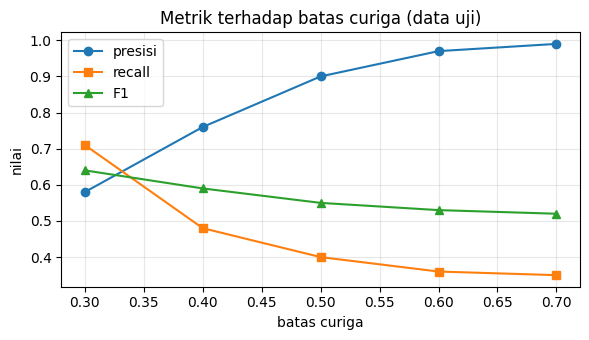

In [12]:
# --- batas 0.3 .. 0.7, presisi/recall/F1, kerugian harapan ---
RUGI_KOSONG, RUGI_TERSINGGUNG = 1.0, 0.3           # juta Rp — ASUMSI, wajib ditulis di laporan
t = tabel_batas(p_uji, y_uji, daftar_batas=np.round(np.arange(0.3, 0.71, 0.1), 1),
                rugi_kosong=RUGI_KOSONG, rugi_tersinggung=RUGI_TERSINGGUNG)
t["F1"] = (2 * t.presisi * t.recall / (t.presisi + t.recall)).round(2)
print(t)
batas_terbaik = t.loc[t.E_rugi_jt.idxmin(), "batas"]
print("Batas dengan kerugian harapan terkecil:", batas_terbaik)

plt.figure(figsize=(6, 3.5))
plt.plot(t.batas, t.presisi, "o-", label="presisi"); plt.plot(t.batas, t.recall, "s-", label="recall"); plt.plot(t.batas, t.F1, "^-", label="F1")
plt.xlabel("batas curiga"); plt.ylabel("nilai"); plt.title("Metrik terhadap batas curiga (data uji)"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig("grafik_metrik_vs_batas.png", dpi=150); plt.show()

In [13]:
# --- bagian wajib: fitur yang menyerupai atribut pribadi (AI 2041 Bab 1) ---
print("Kolom yang menyerupai atribut pribadi tamu:", [c for c in hb.columns if c in ["country", "customer_type", "market_segment", "babies", "children"]])
per_negara = hb.groupby("country")["is_canceled"].agg(["mean", "size"]).query("size >= 500").sort_values("mean", ascending=False)
print(per_negara.head(8).round(3))
# Catatan untuk laporan: 'country' memprediksi batal, tetapi memakainya berarti meminta deposit berdasarkan asal tamu —
# secara statistik "benar", secara hukum/reputasi berbahaya (AI 2041 Bab 1 'The Golden Elephant'; ISO/IEC 42001 Klausul 6.1.4).
# Fitur yang dipakai di atas sengaja TIDAK memuat country.

Kolom yang menyerupai atribut pribadi tamu: ['children', 'babies', 'country', 'market_segment', 'customer_type']
          mean   size
country              
PRT      0.566  48590
CHN      0.462    999
RUS      0.378    632
BRA      0.373   2224
ITA      0.354   3766
NOR      0.298    607
ROU      0.268    500
ESP      0.254   8568
